# 5-A1 作業：Market Meanness Index

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/5-A1_mmi_filter.ipynb)

**對應影片**：第 5 章 作業 5-A1【策略濾網】Market Meanness Index

**和影片的差異**

- 新增的起始筆記本：MMI 濾網已經寫好，直接套到你想測試的策略與幣種。

練習把 MMI 濾網套到不同的策略、幣種或 K 線週期，觀察它能不能減少震盪盤的虧損：

1. 換成第 5-2 單元的趨勢策略（例如 hullma）
2. 換成 ETHUSDT 或其他幣種、換成 4h
3. 試試相反的條件：`mmi < 0.5` 時才做「逆勢」策略

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import numpy as np
import finlab_crypto
from finlab_crypto import Filter, Strategy
from finlab_crypto.indicators import trends

finlab_crypto.setup()
# TODO: 換成你想研究的幣種與週期
ohlcv = finlab_crypto.crawler.get_all_binance('ETHUSDT', '4h')

ETHUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


In [4]:
from finlab_crypto import Filter


# 必須給 timeperiod 預設值
@Filter(timeperiod=20)
def mmi_filter(ohlcv):
    median = ohlcv.close.rolling(mmi_filter.timeperiod).median()
    p1 = ohlcv.close > median
    p2 = ohlcv.close.shift() > median
    mmi = (p1 & p2).astype(int).rolling(mmi_filter.timeperiod).mean()

    # 不想畫圖的話 figures = {}
    figures = {
        'figures': {
            'mmi_index': mmi
        }
    }
    return mmi > 0.5, figures

In [5]:
# TODO: 換成你的策略
@Strategy(name='hullma', n1=20, n2=60)
def trend_strategy(ohlcv):
    fast = trends[trend_strategy.name](ohlcv.close, trend_strategy.n1)
    slow = trends[trend_strategy.name](ohlcv.close, trend_strategy.n2)
    entries = (fast > slow) & (fast.shift() < slow.shift())
    exits = (fast < slow) & (fast.shift() > slow.shift())
    return entries, exits, {'overlaps': {'fast': fast, 'slow': slow}}

## 沒有濾網 vs. 加上 MMI 濾網

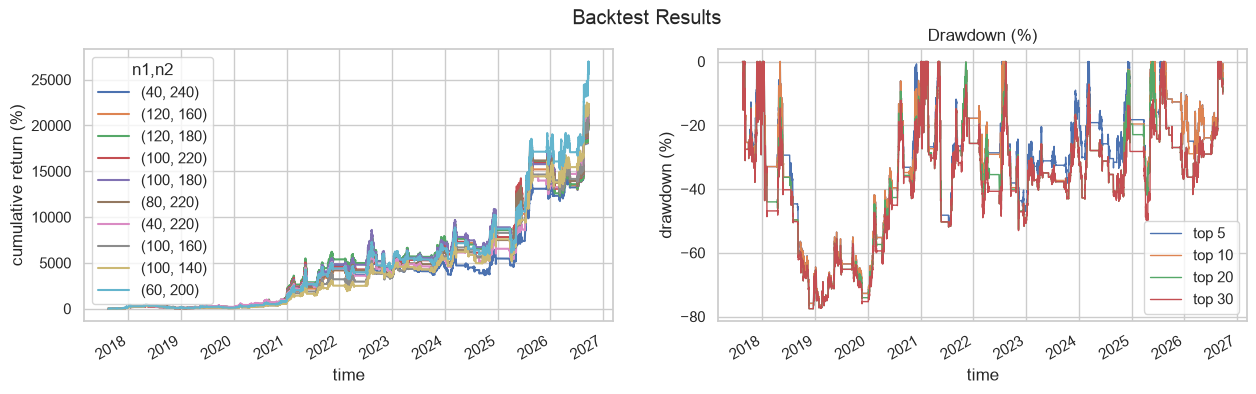

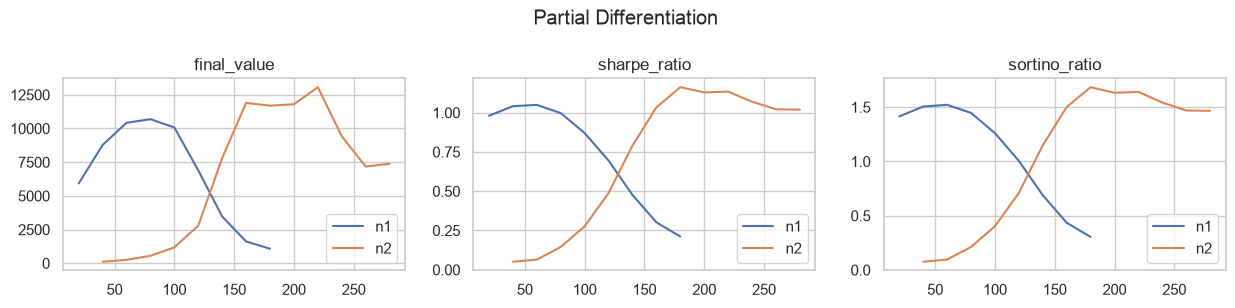

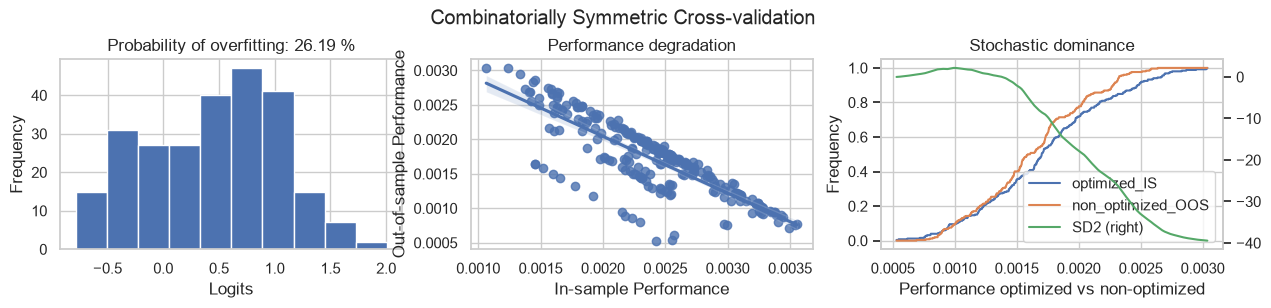

In [6]:
step = 80 if QUICK_RUN else 20
variables = {'n1': np.arange(20, 200, step), 'n2': np.arange(40, 300, step)}

without_filter = trend_strategy.backtest(ohlcv, variables, freq='4h', plot=True)

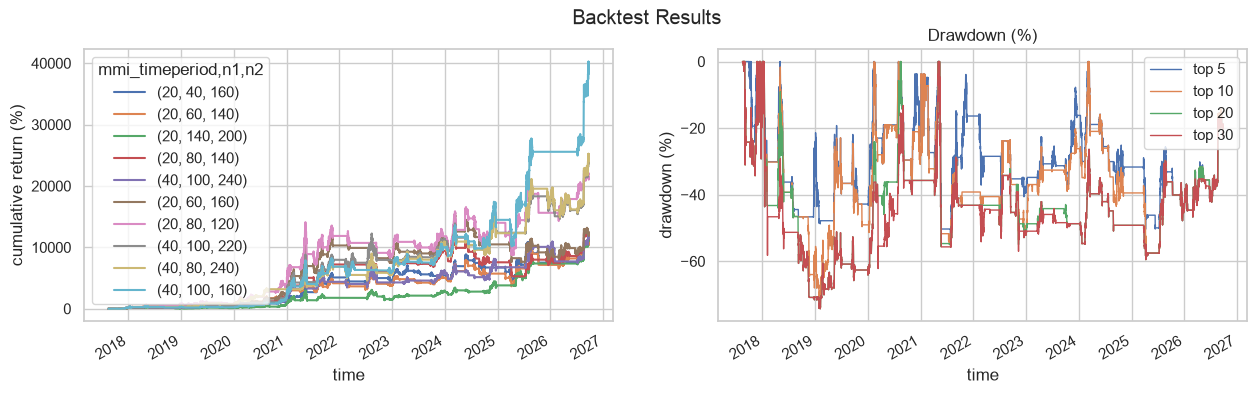

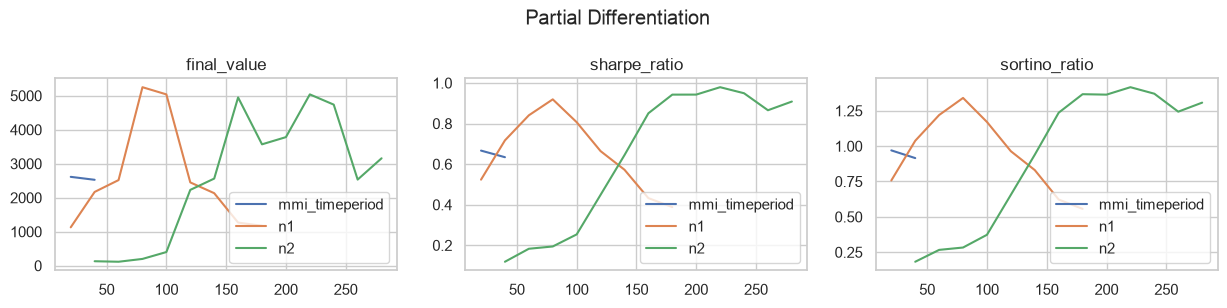

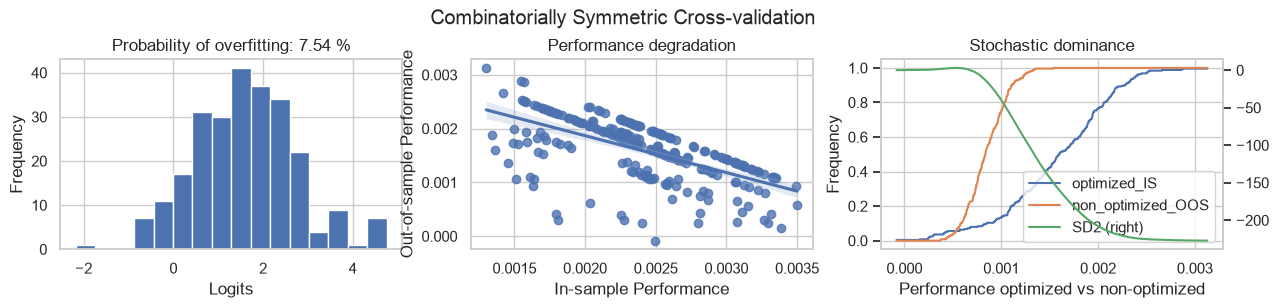

In [7]:
with_filter = trend_strategy.backtest(ohlcv, variables, filters={'mmi': mmi_filter.create({'timeperiod': [20, 40]})},
                                      freq='4h', plot=True)

In [8]:
import pandas as pd

def sharpe_summary(portfolio):
    return portfolio.sharpe_ratio().replace([np.inf, -np.inf], np.nan).describe()


pd.DataFrame({'沒有濾網': sharpe_summary(without_filter), 'MMI 濾網': sharpe_summary(with_filter)})

,沒有濾網,MMI 濾網
count,109.000000,218.000000
mean,0.738173,0.650394
std,0.572654,0.443133
min,-0.361891,-0.502972
25%,0.162123,0.252524
50%,0.975630,0.796093
75%,1.163266,0.997608
max,1.306195,1.459292


## 你的觀察

濾網讓夏普率的分布變好了嗎？過擬合機率呢？